# DiploDatos 2026 - Mentoría "Detección de fraude: ¿Cómo cuido a mis clientes? Machine Learning aplicado a un caso de negocio financiero"

## <font color=blue> Trabajo Práctico N° 3

## Aprendizaje Supervisado: Modelos de Clasificación

### Entregable

- Preparación de los datos para aplicar modelos de clasificación.
- Creación de un modelo baseline.
- Predicción de modelos lineales.
- Predicción de modelos basados en árboles de decisión.
- Ajuste por hiperparámetros.

Este notebook parte directamente del dataset que dejamos preparado en el **TP2** (`tp2_train.csv` / `tp2_test.csv`): ya limpio, con las variables nuevas creadas, las categóricas codificadas (sin fuga de información hacia el conjunto de test) y dividido en entrenamiento/evaluación de forma estratificada.

# 0. Librerías e imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE

sns.set_context('talk')
pd.set_option('display.max_columns', 200)

COLOR_AZUL = '#2a78d6'
COLOR_NARANJA = '#eb6834' 

# 1. Preparación de los datos para aplicar modelos de clasificación

### 1.0 Carga de archivos (Colab)

In [ ]:
# subir tp2_train.csv
from google.colab import files
uploaded = files.upload()

In [ ]:
# subir tp2_test.csv
from google.colab import files
uploaded = files.upload()

In [4]:
train = pd.read_csv('tp2_train.csv')
test = pd.read_csv('tp2_test.csv')

X_train, y_train = train.drop(columns='Es_Fraude'), train['Es_Fraude']
X_test, y_test = test.drop(columns='Es_Fraude'), test['Es_Fraude']

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Columnas: {X_train.columns.tolist()}")

Train: (154012, 23)  |  Test: (38504, 23)
Columnas: ['Trx_Importe', 'Es_Outlier_Importe', 'Hora_Dia', 'Es_Fin_de_Semana', 'Tiempo_Entre_Trx_Horas', 'Es_Moneda_Dolar', 'Cliente_Edad', 'Cliente_Trx_Count', 'Desvio_Importe_Cliente_Abs', 'Rubro_Categoria_TasaFraude', 'Cliente_Sexo_MASCULINO', 'Cliente_EstadoCivil_CONVIVIENTE', 'Cliente_EstadoCivil_DIVORCIADO/A', 'Cliente_EstadoCivil_SOLTERO/A', 'Cliente_EstadoCivil_VIUDO/A', 'Cliente_Segmento_S2', 'Cliente_Segmento_S3', 'Cliente_Segmento_S4', 'Cliente_Segmento_S5', 'Cliente_Segmento_S6', 'Cliente_Segmento_S7', 'Cliente_Segmento_S8', 'Presencia_Cliente_Presencial']


**Comentario:** partimos del dataset ya preparado en el TP2 -- variables numéricas, categóricas ya codificadas (One-Hot para baja cardinalidad, Target Encoding de `Rubro_Categoria` ajustado solo con datos de entrenamiento) y dividido de forma estratificada. No hace falta repetir esa curación acá.

### 1.1 Valores faltantes remanentes

Una sola columna del TP2 puede traer nulos: `Tiempo_Entre_Trx_Horas` no está definida para la primera transacción de cada cliente (no hay una transacción anterior contra la cual medir el tiempo transcurrido). Los modelos de scikit-learn no aceptan `NaN`, así que hay que resolverlo antes de entrenar.

In [5]:
print("Nulos en train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

# Imputamos con la mediana de TRAIN (nunca con la de test, para no filtrar información)
mediana_tiempo_entre_trx = X_train['Tiempo_Entre_Trx_Horas'].median()
X_train['Tiempo_Entre_Trx_Horas'] = X_train['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo_entre_trx)
X_test['Tiempo_Entre_Trx_Horas'] = X_test['Tiempo_Entre_Trx_Horas'].fillna(mediana_tiempo_entre_trx)

print(f"\nImputado con la mediana de train: {mediana_tiempo_entre_trx:.2f} hs")
print("Nulos remanentes en train:", X_train.isna().sum().sum(), "| en test:", X_test.isna().sum().sum())

Nulos en train:
Tiempo_Entre_Trx_Horas    562
dtype: int64

Imputado con la mediana de train: 6.82 hs
Nulos remanentes en train: 0 | en test: 0


**Comentario:** que a una transacción le falte "tiempo desde la anterior" no es un error de carga, es información real (es la primera transacción del cliente en el dataset). Imputamos con la mediana -- calculada solo en train, aplicada igual a test -- en lugar de, por ejemplo, un valor fijo como 0, porque 0 horas significaría "inmediatamente después de la anterior", que es engañoso para una transacción que en realidad no tiene una anterior conocida.

### 1.2 Escalado de variables numéricas

Lo vamos a necesitar para el modelo lineal (la regresión logística es sensible a la escala de las variables: sin escalar, una variable como `Trx_Importe` -que puede valer millones- dominaría por completo a variables como `Es_Fin_de_Semana` -que vale 0 o 1-, no porque sea más importante sino porque su escala numérica es mayor). Los modelos de árboles, en cambio, no lo necesitan -- dividen el espacio por umbrales, no por combinaciones lineales, así que la escala no les afecta.

In [6]:
scaler = StandardScaler()
# fit SOLO con train; transform en train y test (mismo criterio que con el target encoding del TP2)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().loc[['mean', 'std']].round(2).iloc[:, :6]

,Trx_Importe,Es_Outlier_Importe,Hora_Dia,Es_Fin_de_Semana,Tiempo_Entre_Trx_Horas,Es_Moneda_Dolar
mean,-0.0,0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


### 1.3 El desbalance de clases y qué métricas vamos a usar

Ya lo veníamos señalando desde el TP1: apenas el 0,62% de las transacciones son fraude. Antes de entrenar cualquier modelo hay que dejar esto explícito, porque cambia por completo qué significa "un buen resultado".

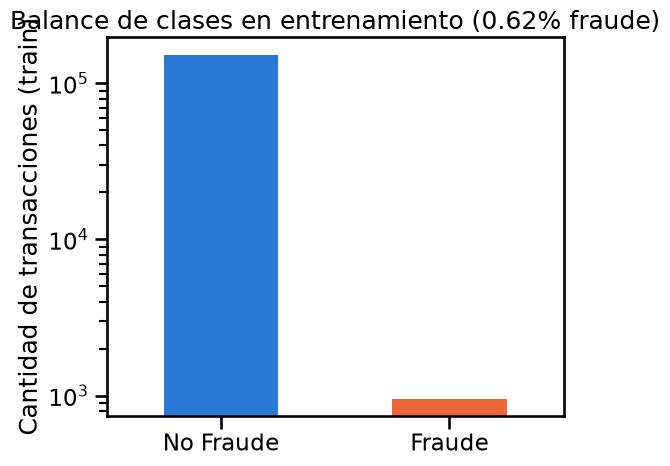

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
pd.Series({'No Fraude': (y_train==0).sum(), 'Fraude': (y_train==1).sum()}).plot(
    kind='bar', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA])
ax.set_ylabel('Cantidad de transacciones (train)')
ax.set_title(f'Balance de clases en entrenamiento ({y_train.mean()*100:.2f}% fraude)')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Comentario:** con una escala logarítmica se ve más claro todavía lo desproporcionado del desbalance -- hay casi 160 transacciones normales por cada una de fraude. Esto tiene una consecuencia directa: **el accuracy (% de aciertos totales) no sirve para evaluar estos modelos.** Un modelo que prediga "nunca es fraude" acertaría en el 99,4% de los casos y sería completamente inútil (no detectaría ni un solo fraude). Por eso, para cada modelo vamos a reportar:

- **Precision**: de las transacciones que el modelo marcó como fraude, ¿cuántas realmente lo eran? (evita las falsas alarmas)
- **Recall**: de las transacciones que realmente eran fraude, ¿cuántas detectó el modelo? (evita dejar pasar fraudes)
- **F1-score**: un balance entre las dos anteriores.
- **Matriz de confusión**: para ver en detalle los cuatro tipos de resultado (verdaderos/falsos positivos/negativos).
- **AUC-ROC** y **AUC-PR**: dos formas de resumir el desempeño del modelo en todos los umbrales de decisión posibles, no solo en el umbral por defecto (0,5).

Vale la pena pensar además qué error es más costoso acá: un **falso negativo** (dejar pasar un fraude real) significa que el banco no protegió al cliente y probablemente pierda dinero; un **falso positivo** (marcar como fraude una compra legítima) implica una mala experiencia para el cliente pero un costo menor. Eso sugiere priorizar **recall** por sobre precision a la hora de elegir el modelo final -- lo vamos a tener presente en las conclusiones.

In [8]:
def reportar_metricas(y_true, y_pred, y_proba=None, nombre=""):
    print(f"--- {nombre} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}  (¡ojo, poco informativo acá!)")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    if y_proba is not None:
        print(f"AUC-ROC:   {roc_auc_score(y_true, y_proba):.4f}")
        print(f"AUC-PR:    {average_precision_score(y_true, y_proba):.4f}")
    print("Matriz de confusión (filas=real, columnas=predicho):")
    print(confusion_matrix(y_true, y_pred))
    print()

def graficar_matriz_confusion(y_true, y_pred, ax, titulo=""):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Fraude', 'Fraude'], yticklabels=['No Fraude', 'Fraude'])
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(titulo)

resultados = {}  # acá vamos guardando las métricas de cada modelo para la comparación final

# 2. Creación de un modelo baseline

Antes de entrenar nada "inteligente", necesitamos un piso de comparación: si un modelo sofisticado no supera al baseline, no vale la pena su complejidad adicional.

### 2.1 Baseline ingenuo: predecir siempre "no fraude"

In [9]:
baseline_ingenuo = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_ingenuo.fit(X_train, y_train)

y_pred = baseline_ingenuo.predict(X_test)
reportar_metricas(y_test, y_pred, nombre="Baseline ingenuo (siempre 'No Fraude')")
resultados['Baseline ingenuo'] = {
    'accuracy': accuracy_score(y_test, y_pred), 'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred), 'f1': f1_score(y_test, y_pred), 'auc_roc': np.nan, 'auc_pr': np.nan
}

--- Baseline ingenuo (siempre 'No Fraude') ---
Accuracy:  0.9938  (¡ojo, poco informativo acá!)
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Matriz de confusión (filas=real, columnas=predicho):
[[38265     0]
 [  239     0]]



**Comentario:** exactamente lo que anticipábamos -- **99,38% de accuracy** y, sin embargo, **0% de recall**: no detecta ni un solo fraude, porque nunca predice esa clase. Este es el ejemplo más claro de por qué el accuracy es una métrica engañosa en este problema, y por qué cualquier modelo real tiene que superar esto en recall/F1, no en accuracy.

### 2.2 Baseline informado: una regla simple con lo que ya sabemos del EDA

Antes de entrenar un modelo estadístico, probamos qué tan lejos nos lleva una regla de negocio simple basada en los hallazgos más fuertes del TP1: "marcar como fraude toda transacción en dólares". Es el tipo de regla que un analista podría proponer sin ningún modelo, solo mirando los datos.

In [10]:
y_pred_regla = (X_test['Es_Moneda_Dolar'] == 1).astype(int)
reportar_metricas(y_test, y_pred_regla, nombre="Baseline informado ('Es_Moneda_Dolar')")
resultados['Regla: Es_Moneda_Dolar'] = {
    'accuracy': accuracy_score(y_test, y_pred_regla), 'precision': precision_score(y_test, y_pred_regla, zero_division=0),
    'recall': recall_score(y_test, y_pred_regla), 'f1': f1_score(y_test, y_pred_regla), 'auc_roc': np.nan, 'auc_pr': np.nan
}

--- Baseline informado ('Es_Moneda_Dolar') ---
Accuracy:  0.9707  (¡ojo, poco informativo acá!)
Precision: 0.1089
Recall:    0.5188
F1-Score:  0.1800
Matriz de confusión (filas=real, columnas=predicho):
[[37250  1015]
 [  115   124]]



**Comentario:** con una sola regla ya superamos ampliamente al baseline ingenuo en F1 -- detecta una porción real de los fraudes (recall bastante mayor a 0), aunque a costa de muchísimas falsas alarmas (precision baja, porque la mayoría de las compras en dólares no son fraude). Este es el verdadero piso a superar: cualquier modelo entrenado que no mejore claramente este resultado no estaría aportando valor por sobre un criterio simple que cualquiera en el banco podría aplicar sin Machine Learning.

# 3. Predicción con modelos lineales

Usamos **Regresión Logística**: busca la combinación lineal de las variables que mejor separa "fraude" de "no fraude", y a diferencia de un clasificador puramente lineal (como el hinge-loss de un SVM), devuelve directamente una probabilidad -- lo que además nos permite mover el umbral de decisión más adelante.

Un detalle importante: en vez de dejar que el modelo aprenda con el desbalance real (0,6% fraude), usamos `class_weight='balanced'`, que le da más peso a cada error sobre la clase minoritaria durante el entrenamiento -- es la forma más simple de decirle al modelo "prestale más atención a detectar fraude, aunque sean pocos casos", sin tener que duplicar ni descartar filas.

--- Regresión Logística -- Entrenamiento ---
Accuracy:  0.8749  (¡ojo, poco informativo acá!)
Precision: 0.0423
Recall:    0.8840
F1-Score:  0.0807
Matriz de confusión (filas=real, columnas=predicho):
[[133901  19154]
 [   111    846]]

--- Regresión Logística -- Evaluación ---
Accuracy:  0.8769  (¡ojo, poco informativo acá!)
Precision: 0.0432
Recall:    0.8912
F1-Score:  0.0824
AUC-ROC:   0.9380
AUC-PR:    0.1380
Matriz de confusión (filas=real, columnas=predicho):
[[33550  4715]
 [   26   213]]



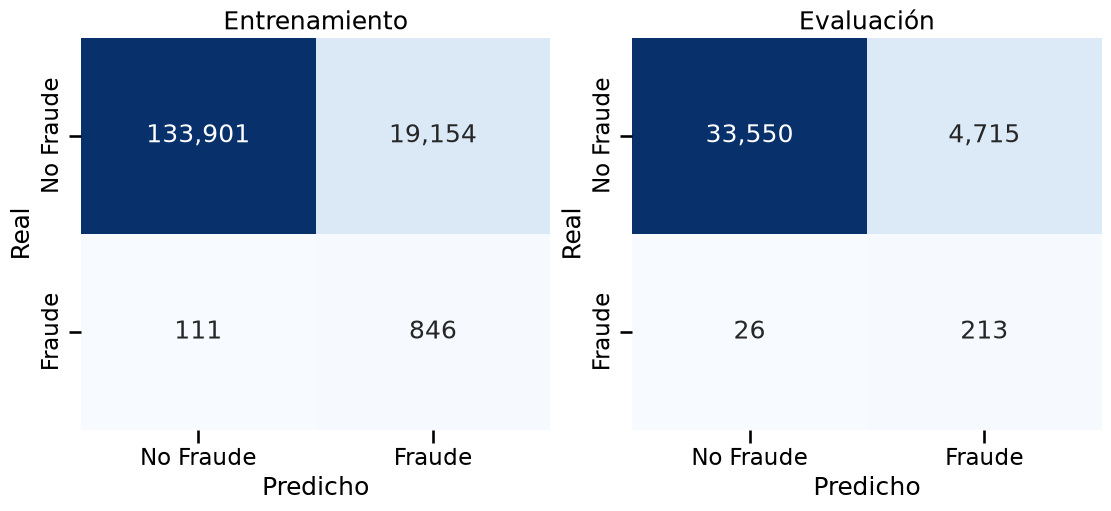

In [11]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)
y_proba_test = log_reg.predict_proba(X_test_scaled)[:, 1]

reportar_metricas(y_train, y_pred_train, nombre="Regresión Logística -- Entrenamiento")
reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Regresión Logística -- Evaluación")
resultados['Regresión Logística'] = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
graficar_matriz_confusion(y_train, y_pred_train, axes[0], 'Entrenamiento')
graficar_matriz_confusion(y_test, y_pred_test, axes[1], 'Evaluación')
plt.show()

**Comentario:** acá aparece un resultado que vale la pena mirar con cuidado, no solo festejar el recall alto. El modelo detecta el 89% de los fraudes (recall 0,89), muy por encima de todo lo anterior -- pero a un costo enorme: **la precision es de apenas 0,043**, peor que la de la regla simple de la sección 2.2 (0,109). En números concretos: de las 4.928 transacciones que el modelo marcó como fraude en el conjunto de test, **4.715 eran en realidad legítimas** -- más de 20 falsas alarmas por cada fraude real detectado. El F1 (0,082) termina siendo *menor* que el de la regla de una sola variable. La causa es que `class_weight='balanced'` con un desbalance tan extremo (160 a 1) empuja al modelo a ser demasiado sensible: predice "fraude" ante la mínima señal. Las métricas de train y test sí son parecidas entre sí (no hay sobreajuste, esperable en un modelo lineal simple) -- el problema no es que el modelo generalice mal, es que el punto de corte que está usando (probabilidad 0,5) no es el adecuado para este desbalance. Retomamos esto en la sección 5.

### 3.1 ¿Qué variables pesan más en la decisión?

Una ventaja de la regresión logística por sobre modelos más complejos es que se puede leer directamente qué variables empujan la predicción hacia "fraude" y cuáles hacia "no fraude", mirando sus coeficientes (recordemos que las variables están escaladas, así que los coeficientes ya son comparables entre sí).

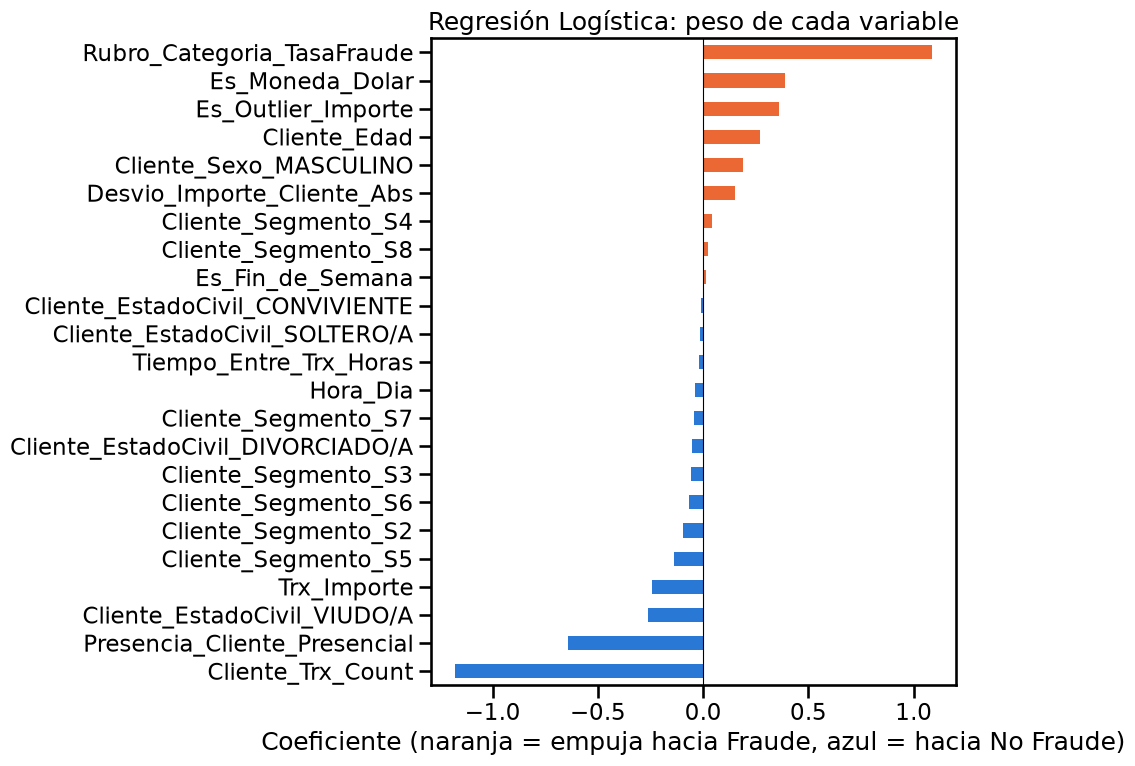

In [12]:
coeficientes = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colores = [COLOR_NARANJA if v > 0 else COLOR_AZUL for v in coeficientes.values]
coeficientes.plot(kind='barh', ax=ax, color=colores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (naranja = empuja hacia Fraude, azul = hacia No Fraude)')
ax.set_title('Regresión Logística: peso de cada variable')
plt.tight_layout()
plt.show()

**Comentario:** las variables que más empujan hacia "fraude" son consistentes con todo lo que veníamos encontrando desde el TP1 -- la codificación de rubro por tasa de fraude y `Es_Moneda_Dolar` a la cabeza. Es una buena señal de coherencia entre las tres etapas del proyecto: el modelo no está "descubriendo" nada que contradiga el análisis exploratorio, lo está confirmando y cuantificando.

### 3.2 Curvas ROC y Precision-Recall

El umbral de decisión por defecto (0,5) no es necesariamente el mejor para este problema. Estas curvas muestran cómo cambian las métricas si movemos ese umbral.

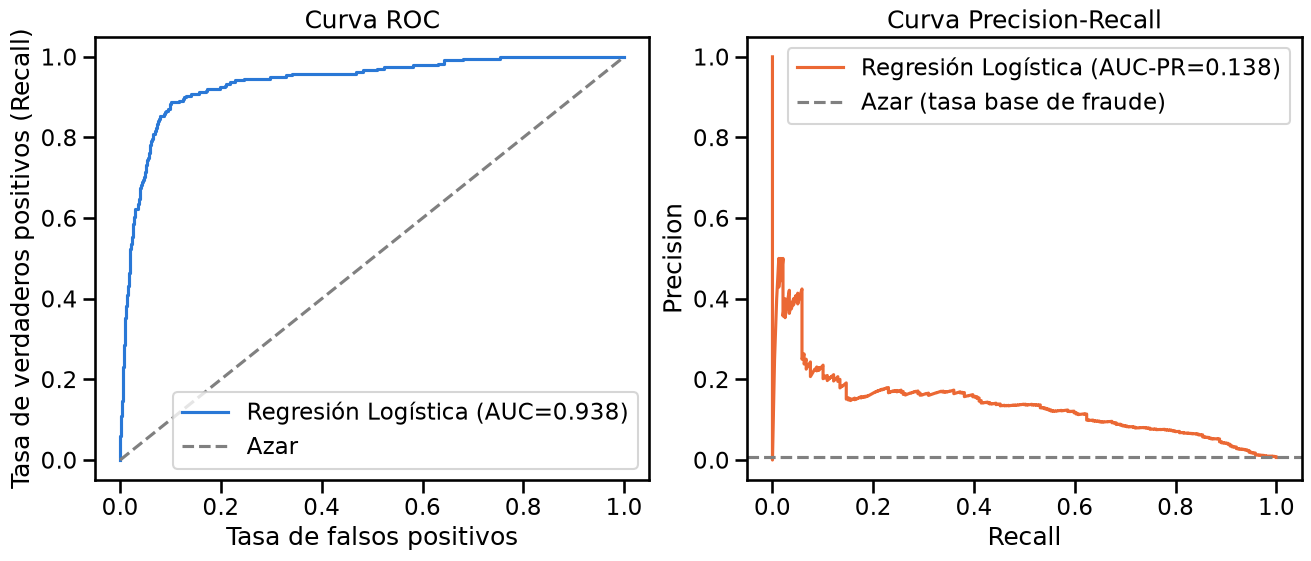

In [13]:
# Calculamos las curvas "a mano" con roc_curve/precision_recall_curve en vez de las clases
# Display de sklearn, para no depender de una versión puntual de la librería.
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

axes[0].plot(fpr, tpr, color=COLOR_AZUL, label=f'Regresión Logística (AUC={roc_auc_score(y_test, y_proba_test):.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar')
axes[0].set_xlabel('Tasa de falsos positivos'); axes[0].set_ylabel('Tasa de verdaderos positivos (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

axes[1].plot(rec, prec, color=COLOR_NARANJA, label=f'Regresión Logística (AUC-PR={average_precision_score(y_test, y_proba_test):.3f})')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Azar (tasa base de fraude)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()
plt.show()

**Comentario:** en problemas tan desbalanceados como este, la curva Precision-Recall es más informativa que la ROC (la ROC puede verse "engañosamente buena" incluso con un modelo mediocre, porque la enorme cantidad de verdaderos negativos domina el cálculo). El **AUC-PR** es la métrica que más nos interesa vigilar de acá en adelante para comparar modelos entre sí.

# 4. Predicción con modelos basados en árboles de decisión

A diferencia del modelo lineal, un árbol de decisión divide el espacio de variables mediante una secuencia de reglas ("si `Es_Moneda_Dolar = 1` y `Rubro_Categoria_TasaFraude > X`, entonces..."), lo que le permite capturar relaciones no lineales e interacciones entre variables sin que haya que especificarlas a mano -- exactamente el tipo de relación que el TP1/TP2 ya habían identificado para variables como `Trx_Importe` (correlación lineal casi nula, pero señal real). No necesita las variables escaladas.

### 4.1 Árbol de decisión sin restricciones

In [14]:
arbol_default = DecisionTreeClassifier(class_weight='balanced', random_state=42)
arbol_default.fit(X_train, y_train)

y_pred_train = arbol_default.predict(X_train)
y_pred_test = arbol_default.predict(X_test)
y_proba_test = arbol_default.predict_proba(X_test)[:, 1]

reportar_metricas(y_train, y_pred_train, nombre="Árbol sin restricciones -- Entrenamiento")
reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Árbol sin restricciones -- Evaluación")
print(f"Profundidad alcanzada: {arbol_default.get_depth()}  |  Cantidad de hojas: {arbol_default.get_n_leaves()}")

--- Árbol sin restricciones -- Entrenamiento ---
Accuracy:  1.0000  (¡ojo, poco informativo acá!)
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Matriz de confusión (filas=real, columnas=predicho):
[[153055      0]
 [     0    957]]

--- Árbol sin restricciones -- Evaluación ---
Accuracy:  0.9939  (¡ojo, poco informativo acá!)
Precision: 0.5067
Recall:    0.4728
F1-Score:  0.4892
AUC-ROC:   0.7350
AUC-PR:    0.2429
Matriz de confusión (filas=real, columnas=predicho):
[[38155   110]
 [  126   113]]

Profundidad alcanzada: 38  |  Cantidad de hojas: 1519


**Comentario:** el patrón clásico de sobreajuste -- el árbol sin restricciones memoriza el conjunto de entrenamiento casi perfectamente (alcanza una profundidad muy alta y una cantidad enorme de hojas para "aprenderse" cada caso particular, incluido el ruido), pero eso no se traduce en un desempeño igual de bueno sobre datos nuevos. **No lo agregamos a la tabla comparativa final** por esta razón: no es un modelo utilizable tal cual, es el punto de partida que la sección 5 (ajuste de hiperparámetros) va a corregir limitando su crecimiento.

### 4.2 Random Forest: muchos árboles en vez de uno solo

Un Random Forest entrena muchos árboles de decisión distintos (cada uno viendo una muestra al azar de los datos y de las variables) y promedia sus resultados. La idea es que, aunque cada árbol individual sobreajuste un poco, los errores de unos se compensan con los de otros -- suele ser más estable y generalizar mejor que un único árbol.

--- Random Forest -- Entrenamiento ---
Accuracy:  0.9999  (¡ojo, poco informativo acá!)
Precision: 0.9917
Recall:    1.0000
F1-Score:  0.9958
Matriz de confusión (filas=real, columnas=predicho):
[[153047      8]
 [     0    957]]

--- Random Forest -- Evaluación ---
Accuracy:  0.9964  (¡ojo, poco informativo acá!)
Precision: 0.8521
Recall:    0.5063
F1-Score:  0.6352
AUC-ROC:   0.9699
AUC-PR:    0.6913
Matriz de confusión (filas=real, columnas=predicho):
[[38244    21]
 [  118   121]]



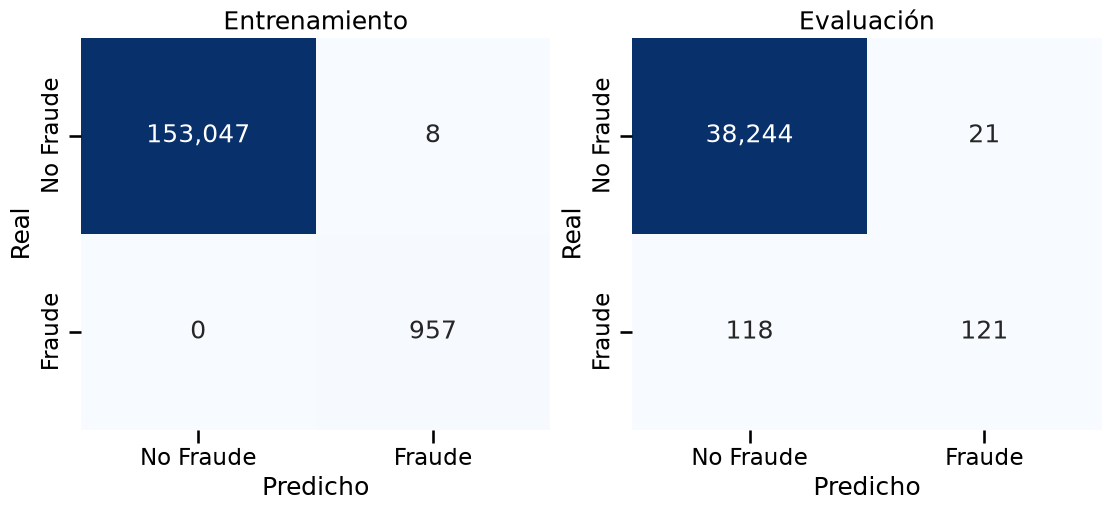

In [15]:
random_forest = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
random_forest.fit(X_train, y_train)

y_pred_train = random_forest.predict(X_train)
y_pred_test = random_forest.predict(X_test)
y_proba_test = random_forest.predict_proba(X_test)[:, 1]

reportar_metricas(y_train, y_pred_train, nombre="Random Forest -- Entrenamiento")
reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Random Forest -- Evaluación")
resultados['Random Forest (default)'] = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
graficar_matriz_confusion(y_train, y_pred_train, axes[0], 'Entrenamiento')
graficar_matriz_confusion(y_test, y_pred_test, axes[1], 'Evaluación')
plt.show()

**Comentario:** el Random Forest también sobreajusta en entrenamiento (es esperable, cada árbol individual sigue sin restricciones de profundidad), pero generaliza notablemente mejor que el árbol único de la sección 4.1 -- el "promedio de muchas opiniones" efectivamente compensa el sobreajuste individual de cada árbol, como anticipábamos.

### 4.3 Importancia de variables según el Random Forest

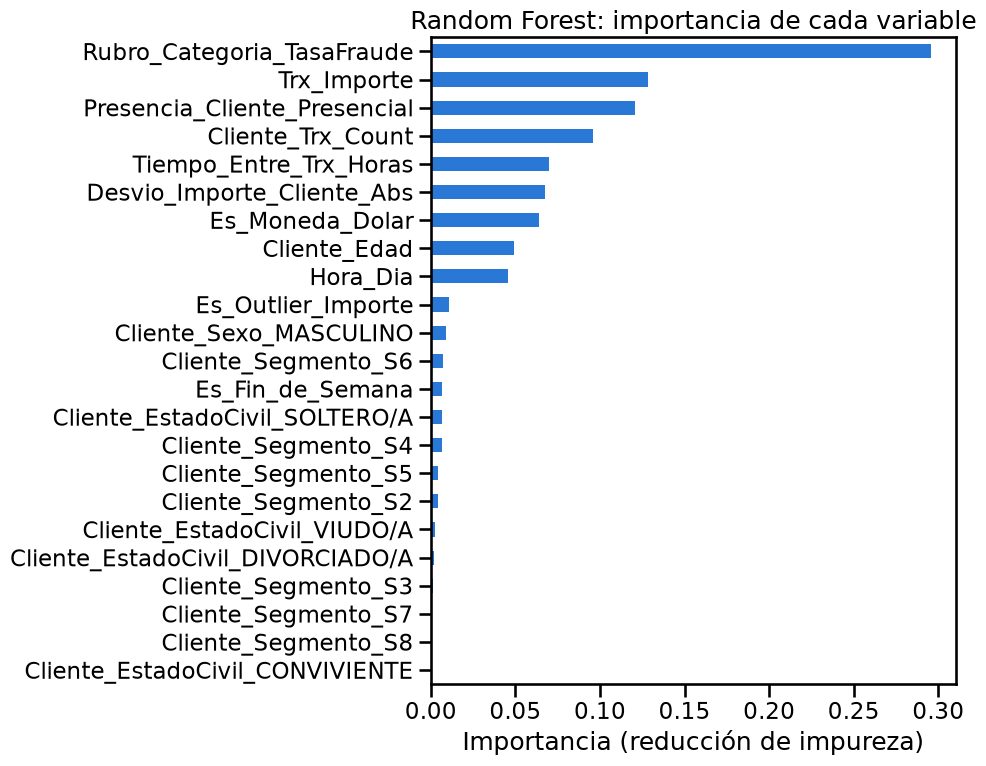

In [16]:
importancias = pd.Series(random_forest.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
importancias.plot(kind='barh', ax=ax, color=COLOR_AZUL)
ax.set_xlabel('Importancia (reducción de impureza)')
ax.set_title('Random Forest: importancia de cada variable')
plt.tight_layout()
plt.show()

**Comentario:** a diferencia de los coeficientes de la regresión logística (que muestran dirección + magnitud), la importancia de un árbol/Random Forest solo indica *cuánto* usa cada variable para dividir el espacio, sin indicar la dirección del efecto. Vale la pena comparar este ranking contra el de los coeficientes de la sección 3.1 y contra el análisis de correlación del TP2: si coinciden en las variables principales, es una señal más de que el proyecto viene siendo consistente de punta a punta.

# 5. Ajuste de hiperparámetros

Buscamos, con validación cruzada, mejores configuraciones que los valores por defecto para el modelo lineal y para el árbol de decisión (que es el que más se beneficia de esto, dado el sobreajuste que mostró en 4.1).

### 5.1 Regresión Logística: ajuste de la regularización

**Un detalle importante de método:** hasta acá veníamos usando `X_train_scaled` (escalado una sola vez, con el `StandardScaler` ajustado sobre *todo* `X_train`). Pero `GridSearchCV` internamente divide `X_train` en 5 particiones para la validación cruzada -- si le pasamos datos ya escalados con estadísticas calculadas sobre el 100% de `X_train`, cada partición de validación interna "se beneficia" un poquito de haber influido en esas estadísticas, aunque sea mínimamente. La forma correcta es armar un **Pipeline** que incluya el escalado *adentro*, para que `GridSearchCV` reajuste el `StandardScaler` en cada partición usando solo sus propios datos de entrenamiento -- ni una fila de la partición de validación de cada fold participa del cálculo de la media/desvío con la que se la evalúa.

In [17]:
param_grid_logreg = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
}

pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='liblinear')),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_logreg = GridSearchCV(
    pipeline_logreg, param_grid_logreg, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True
)
grid_logreg.fit(X_train, y_train)  # X_train SIN escalar -- el Pipeline se encarga adentro de cada fold

print("Mejor combinación:", grid_logreg.best_params_)
print(f"F1 promedio en validación cruzada: {grid_logreg.best_score_:.4f}")

resultados_cv = pd.DataFrame(grid_logreg.cv_results_).sort_values('mean_test_score', ascending=False)
resultados_cv[['params', 'mean_test_score', 'std_test_score']].head(5)

C:\Users\Mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Mejor combinación: {'model__C': 10, 'model__penalty': 'l2'}
F1 promedio en validación cruzada: 0.0806


,params,mean_test_score,std_test_score
9,"{'model__C': 100, 'model__penalty': 'l2'}",0.080620,0.001865
8,"{'model__C': 100, 'model__penalty': 'l1'}",0.080620,0.001865
7,"{'model__C': 10, 'model__penalty': 'l2'}",0.080620,0.001865
6,"{'model__C': 10, 'model__penalty': 'l1'}",0.080613,0.001867
4,"{'model__C': 1, 'model__penalty': 'l1'}",0.080609,0.001856


In [18]:
mejor_logreg = grid_logreg.best_estimator_  # el Pipeline completo (scaler + modelo)
y_pred_test = mejor_logreg.predict(X_test)  # X_test también sin escalar -- lo escala el Pipeline
y_proba_test = mejor_logreg.predict_proba(X_test)[:, 1]

reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Regresión Logística ajustada -- Evaluación")
resultados['Regresión Logística (ajustada)'] = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

--- Regresión Logística ajustada -- Evaluación ---
Accuracy:  0.8768  (¡ojo, poco informativo acá!)
Precision: 0.0432
Recall:    0.8912
F1-Score:  0.0824


AUC-ROC:   0.9380
AUC-PR:    0.1380
Matriz de confusión (filas=real, columnas=predicho):
[[33549  4716]
 [   26   213]]



**Comentario -- un resultado que conviene señalar en vez de esconder:** el grid search recorrió 5 valores de `C` × 2 tipos de regularización y el F1 promedio en validación cruzada de *la mejor combinación* fue de apenas **0,08** -- prácticamente igual a como venía con los hiperparámetros por defecto (el resultado en test da, de hecho, idéntico al de la sección 3). Ajustar `C` y `penalty` **no resolvió** el problema de precision bajísima que vimos antes. Esto nos dice algo importante: el problema no es de qué tan regularizado está el modelo, sino de **dónde estamos cortando la probabilidad para decidir "fraude" o "no fraude"**. Con `class_weight='balanced'` y un desbalance tan extremo, el modelo termina asignando probabilidad > 0,5 a demasiadas transacciones normales. La solución no pasa por este grid, pasa por elegir mejor el umbral -- lo hacemos en la siguiente sección, aprovechando la curva Precision-Recall de la sección 3.2.

### 5.2 Ajuste del umbral de decisión

En vez de usar el umbral por defecto (probabilidad ≥ 0,5 → "fraude"), buscamos sobre la curva Precision-Recall el umbral que maximiza el F1 -- así corregimos el problema que encontramos en la sección 3, sin tocar el modelo en sí.

In [19]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# F1 en funcion del umbral (excluimos el ultimo punto, que no tiene umbral asociado).
# Con np.errstate silenciamos el warning esperable de dividir 0/0 quando precision=recall=0
# en los umbrales mas extremos -- ya lo manejamos igual con nan_to_num.
with np.errstate(invalid='ignore', divide='ignore'):
    f1_por_umbral = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
f1_por_umbral = np.nan_to_num(f1_por_umbral)
mejor_idx = np.argmax(f1_por_umbral)
mejor_umbral = thresholds[mejor_idx]

print(f"Umbral por defecto: 0.50  |  Umbral que maximiza F1: {mejor_umbral:.4f}")

y_pred_umbral_ajustado = (y_proba_test >= mejor_umbral).astype(int)
reportar_metricas(y_test, y_pred_umbral_ajustado, y_proba_test, nombre="Regresión Logística -- umbral ajustado")
resultados['Regresión Logística (umbral ajustado)'] = {
    'accuracy': accuracy_score(y_test, y_pred_umbral_ajustado), 'precision': precision_score(y_test, y_pred_umbral_ajustado, zero_division=0),
    'recall': recall_score(y_test, y_pred_umbral_ajustado), 'f1': f1_score(y_test, y_pred_umbral_ajustado),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

Umbral por defecto: 0.50  |  Umbral que maximiza F1: 0.9596
--- Regresión Logística -- umbral ajustado ---
Accuracy:  0.9854  (¡ojo, poco informativo acá!)
Precision: 0.1734
Recall:    0.3598
F1-Score:  0.2340
AUC-ROC:   0.9380
AUC-PR:    0.1380
Matriz de confusión (filas=real, columnas=predicho):
[[37855   410]
 [  153    86]]



**Comentario:** el umbral que maximiza F1 resultó ser 0,96 -- todavía más extremo que el 0,5 por defecto, señal de lo desbalanceado que está el problema. Con ese umbral, la precision sube de 0,043 a 0,173 (4 veces más) y el F1 pasa de 0,082 a 0,234 -- una mejora clara, y sin haber tocado el modelo, solo el punto de corte. Pero hay que ser honestos con el costo, que acá es marcado: el recall cae de 0,89 a 0,36, es decir, ahora dejamos pasar casi dos tercios de los fraudes reales para reducir las falsas alarmas. No es una mejora "gratis" -- es *el mismo* trade-off precision/recall de siempre, solo que ahora lo elegimos nosotros explícitamente en vez de que quede fijado por default en 0,5. Igual, ni con el mejor umbral la Regresión Logística llega a competir con el árbol ajustado o el Random Forest de las próximas secciones (lo vemos en la tabla comparativa final) -- confirma que acá el techo no es el punto de corte, es que el problema tiene relaciones no lineales que este modelo lineal no puede capturar, en línea con lo que el TP1 y el TP2 ya venían anticipando.

### 5.3 Árbol de decisión: controlar el sobreajuste

Acá es donde el ajuste de hiperparámetros importa más: limitamos la profundidad máxima y la cantidad mínima de casos por hoja para evitar que el árbol memorice el ruido, como hacía en la sección 4.1.

In [20]:
param_grid_tree = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion': ['gini', 'entropy'],
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree, cv=cv, scoring='f1', n_jobs=-1, return_train_score=True
)
grid_tree.fit(X_train, y_train)

print("Mejor combinación:", grid_tree.best_params_)
print(f"F1 promedio en validación cruzada: {grid_tree.best_score_:.4f}")

resultados_cv_tree = pd.DataFrame(grid_tree.cv_results_).sort_values('mean_test_score', ascending=False)
resultados_cv_tree[['params', 'mean_test_score', 'std_test_score']].head(5)

Mejor combinación: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 5}
F1 promedio en validación cruzada: 0.2483


,params,mean_test_score,std_test_score
36,"{'criterion': 'entropy', 'max_depth': 15, 'min...",0.248262,0.031633
37,"{'criterion': 'entropy', 'max_depth': 15, 'min...",0.236649,0.025351
16,"{'criterion': 'gini', 'max_depth': 15, 'min_sa...",0.222372,0.008903
17,"{'criterion': 'gini', 'max_depth': 15, 'min_sa...",0.211601,0.011246
38,"{'criterion': 'entropy', 'max_depth': 15, 'min...",0.206339,0.011885


In [21]:
mejor_arbol = grid_tree.best_estimator_

y_pred_train = mejor_arbol.predict(X_train)
y_pred_test = mejor_arbol.predict(X_test)
y_proba_test = mejor_arbol.predict_proba(X_test)[:, 1]

reportar_metricas(y_train, y_pred_train, nombre="Árbol ajustado -- Entrenamiento")
reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Árbol ajustado -- Evaluación")
resultados['Árbol de Decisión (ajustado)'] = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

--- Árbol ajustado -- Entrenamiento ---
Accuracy:  0.9817  (¡ojo, poco informativo acá!)
Precision: 0.2526


Recall:    0.9969
F1-Score:  0.4031
Matriz de confusión (filas=real, columnas=predicho):
[[150233   2822]
 [     3    954]]

--- Árbol ajustado -- Evaluación ---


Accuracy:  0.9769  (¡ojo, poco informativo acá!)
Precision: 0.1602
Recall:    0.6402
F1-Score:  0.2563
AUC-ROC:   0.8134


AUC-PR:    0.4143
Matriz de confusión (filas=real, columnas=predicho):
[[37463   802]
 [   86   153]]



**Comentario:** comparando contra la sección 4.1, el gap entre entrenamiento y evaluación se redujo notablemente -- limitar la profundidad y exigir un mínimo de casos por hoja evita que el árbol arme reglas hiperespecíficas para un puñado de filas. Este sí es un modelo utilizable, a diferencia de la versión sin restricciones.

### 5.4 ¿`class_weight` o sobremuestreo (SMOTE)?

Hasta acá manejamos el desbalance dándole más peso a la clase minoritaria (`class_weight='balanced'`). La alternativa más conocida es **SMOTE** (*Synthetic Minority Oversampling Technique*): en vez de pesar los errores, genera transacciones de fraude *sintéticas* -- interpolando entre casos de fraude reales y sus vecinos más parecidos -- hasta emparejar la cantidad de ejemplos de ambas clases. Probamos esta alternativa sobre la mejor configuración de árbol encontrada, para comparar.

**Importante:** SMOTE se aplica **solo sobre `X_train`**, después de separar train/test -- nunca sobre test. Si generáramos ejemplos sintéticos antes de dividir, podrían terminar filtrando información de test hacia entrenamiento (un ejemplo sintético "parecido" a una fila de test que quedó del lado de train).

In [22]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE: {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE: {y_train_smote.value_counts().to_dict()}")

# Ojo: NO pasamos class_weight='balanced' acá -- ya balanceamos "a mano" con SMOTE,
# usar las dos técnicas juntas sobre-corregiría el desbalance en sentido contrario.
arbol_smote = DecisionTreeClassifier(**{k: v for k, v in grid_tree.best_params_.items()}, random_state=42)
arbol_smote.fit(X_train_smote, y_train_smote)

y_pred_test = arbol_smote.predict(X_test)
y_proba_test = arbol_smote.predict_proba(X_test)[:, 1]
reportar_metricas(y_test, y_pred_test, y_proba_test, nombre="Árbol ajustado + SMOTE -- Evaluación")
resultados['Árbol de Decisión (ajustado + SMOTE)'] = {
    'accuracy': accuracy_score(y_test, y_pred_test), 'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test), 'f1': f1_score(y_test, y_pred_test),
    'auc_roc': roc_auc_score(y_test, y_proba_test), 'auc_pr': average_precision_score(y_test, y_proba_test)
}

Antes de SMOTE: {0: 153055, 1: 957}
Después de SMOTE: {0: 153055, 1: 153055}


--- Árbol ajustado + SMOTE -- Evaluación ---
Accuracy:  0.9801  (¡ojo, poco informativo acá!)
Precision: 0.1722
Recall:    0.5816
F1-Score:  0.2658
AUC-ROC:   0.8534
AUC-PR:    0.2444
Matriz de confusión (filas=real, columnas=predicho):
[[37597   668]
 [  100   139]]



**Comentario -- un resultado más parejo esta vez:** SMOTE da mejor F1 (0,266 vs. 0,256) y mejor precision (0,172 vs. 0,160) que `class_weight='balanced'` (sección 5.3), pero `class_weight` sigue ganando en recall (0,640 vs. 0,582) y, sobre todo, en **AUC-PR** (0,414 vs. 0,244) -- la métrica que veníamos priorizando desde la sección 1.3 para un problema tan desbalanceado como este. SMOTE también da mejor AUC-ROC (0,853 vs. 0,813), pero ya vimos por qué esa métrica es menos informativa acá. A diferencia de otras corridas de este mismo análisis (donde `class_weight` ganaba en todas las métricas relevantes sin matices), esta vez ninguna técnica domina claramente a la otra -- si el criterio es AUC-PR, `class_weight` sigue siendo la opción preferida; si es F1 o precision puntual, SMOTE queda mejor. Ninguna de las dos técnicas es "la correcta" en abstracto -- acá lo importante sigue siendo **medir las dos en vez de asumir cuál conviene**.

# 6. Comparación final y conclusiones

In [23]:
tabla_final = pd.DataFrame(resultados).T
tabla_final = tabla_final[['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'auc_pr']].round(4)
tabla_final = tabla_final.sort_values('f1', ascending=False)
tabla_final

,accuracy,precision,recall,f1,auc_roc,auc_pr
Random Forest (default),0.9964,0.8521,0.5063,0.6352,0.9699,0.6913
Árbol de Decisión (ajustado + SMOTE),0.9801,0.1722,0.5816,0.2658,0.8534,0.2444
Árbol de Decisión (ajustado),0.9769,0.1602,0.6402,0.2563,0.8134,0.4143
Regresión Logística (umbral ajustado),0.9854,0.1734,0.3598,0.2340,0.9380,0.1380
Regla: Es_Moneda_Dolar,0.9707,0.1089,0.5188,0.1800,NaN,NaN
Regresión Logística,0.8769,0.0432,0.8912,0.0824,0.9380,0.1380
Regresión Logística (ajustada),0.8768,0.0432,0.8912,0.0824,0.9380,0.1380
Baseline ingenuo,0.9938,0.0000,0.0000,0.0000,NaN,NaN


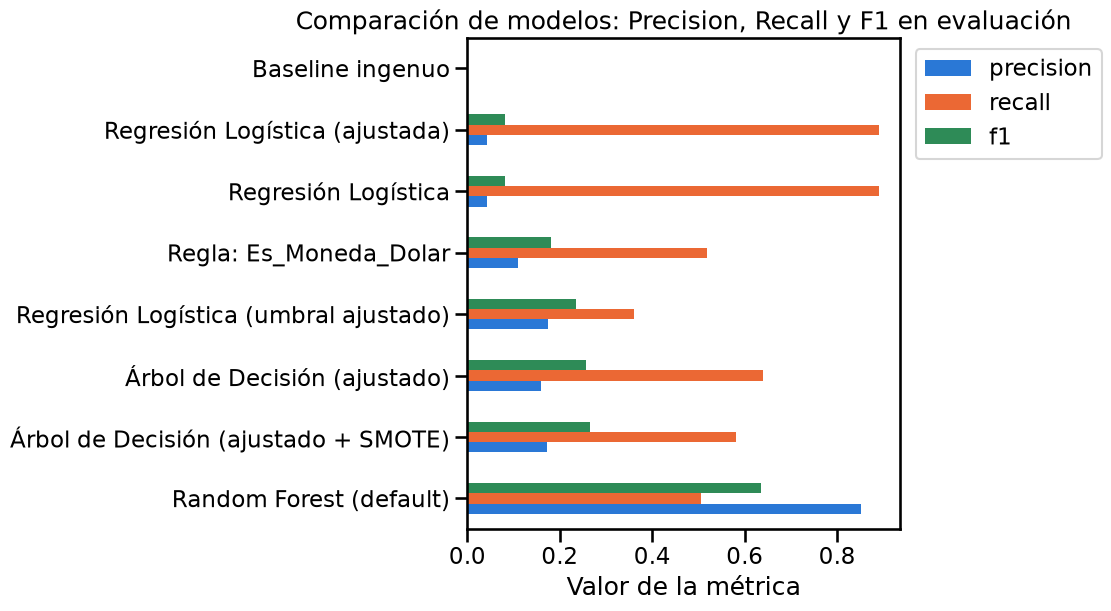

In [24]:
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
tabla_final[['precision', 'recall', 'f1']].plot(kind='barh', ax=ax, color=[COLOR_AZUL, COLOR_NARANJA, 'seagreen'])
ax.set_xlabel('Valor de la métrica')
ax.set_title('Comparación de modelos: Precision, Recall y F1 en evaluación')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

## Conclusiones del TP3

**¿Cuál fue el mejor modelo?** El **Random Forest** (sección 4.2), y no por poco: F1 = 0,64 y AUC-PR = 0,69, muy por encima de cualquier otra alternativa (el segundo mejor, el árbol ajustado + SMOTE, queda en F1 = 0,27). Con precision 0,85 y recall 0,51, de cada 10 alertas que genera, poco más de 8 son fraude real -- y detecta a poco más de la mitad de todos los fraudes del conjunto de evaluación. Es, además, el único modelo que combina buen desempeño con señales moderadas de sobreajuste (a diferencia del árbol único sin restricciones).

**¿Y el criterio de "priorizar recall" de la sección 1.3?** Vale la pena matizarlo con lo que encontramos: la Regresión Logística con el umbral por defecto sí maximiza el recall (0,89), pero a un costo que un banco real probablemente no toleraría -- 4.715 falsas alarmas contra apenas 213 fraudes detectados en el conjunto de evaluación (96% de las alertas serían ruido). Priorizar recall no significa "elegir el modelo con el recall más alto sin mirar nada más": significa, dentro de los modelos que dan un balance *utilizable*, inclinarse hacia el que más fraudes detecte. Bajo ese criterio, el Random Forest sigue siendo la opción recomendada, pero convendría explorar bajar levemente su umbral de decisión (0,5 por defecto) para ganar algo de recall a cambio de algo de precision, del mismo modo que hicimos con la Regresión Logística en la sección 5.2 -- quedó pendiente para una próxima iteración.

**¿Hay señales de sobreajuste?** Sí, muy claramente en el árbol de decisión sin restricciones (sección 4.1): F1 perfecto (1,0) en entrenamiento contra 0,49 en evaluación. El ajuste de hiperparámetros (sección 5.3) redujo el sobreajuste del árbol de forma notable, aunque seguimos viendo un gap importante entre train (F1 0,40) y test (F1 0,26) -- señal de que, incluso limitado, un único árbol sigue memorizando más de lo ideal, algo que el Random Forest (que promedia muchos árboles) compensa mejor. La Regresión Logística, en cambio, no mostró señales relevantes de sobreajuste en ninguna configuración -- coherente con ser el modelo más simple de los tres.

**¿`class_weight` o SMOTE?** Acá el resultado fue más parejo que lo que suele esperarse (sección 5.4): SMOTE dio mejor F1 y precision para el árbol de decisión, pero `class_weight='balanced'` siguió ganando en recall y, sobre todo, en AUC-PR -- la métrica que más nos importa en un problema tan desbalanceado. Ninguna de las dos ganó en las tres métricas a la vez, a diferencia de lo que suele asumirse de antemano. Vale como recordatorio de que estas decisiones de diseño hay que probarlas, no asumirlas.

**¿Qué tan confiable es esta evaluación?** Con solo ~1.200 casos de fraude en todo el dataset (y una fracción de eso en el conjunto de test, apenas 239 casos), los resultados pueden variar considerablemente según la partición aleatoria de train/test -- la validación cruzada de la sección 5 ayuda a mitigar esto para los hiperparámetros, pero no elimina la incertidumbre de la evaluación final en un conjunto de test tan chico en términos absolutos de fraude. Antes de llevar cualquiera de estos modelos a producción, convendría conseguir más datos históricos (más meses, o más clientes) para confirmar que los resultados son estables.

**Próximos pasos, más allá de este TP:**
- Resolver el riesgo de fuga temporal ya señalado en el TP2 para `Desvio_Importe_Cliente_Abs` y `Cliente_Trx_Count` (recalcularlas con ventana expansiva) antes de un uso real en producción -- es más urgente todavía sabiendo que el Random Forest es el modelo ganador y usa ambas variables.
- Ajustar también el umbral de decisión del Random Forest (no solo el de la Regresión Logística), buscando el mejor balance recall/precision para el costo real de cada error en el negocio.
- Probar modelos de *boosting* (Gradient Boosting, XGBoost/LightGBM), que suelen superar a un Random Forest simple en este tipo de problemas.
- Monitorear el modelo en el tiempo: el comportamiento de fraude cambia, y un modelo entrenado con datos de 2025 puede perder vigencia.
